Core libraries imported.
Project directories ready.
Environment loaded. Model tiers:
  WEAK   -> gpt-4o-mini
  MID    -> gpt-5.4-mini
  STRONG -> gpt-5.4
Conditions: ['C1', 'C2', 'C3', 'C4', 'C5']
Datasets   : ['D1', 'D2', 'D2_fin', 'D3']
Grayscale plotting style configured.
Condition styles: {'C1': '0.15', 'C2': '0.3', 'C3': '0.45', 'C4': '0.6', 'C5': '0.75'}
Live check skipped (set RUN_LIVE_CHECK=True to test credentials).
Setup complete. Config snapshot saved.
Loaded full results: n=32598.
Rows per (condition, join_bucket):


condition,C2,C3,C4
join_bucket,,,
0,1983,1983,1989
1,2103,2103,2157
2,435,435,453
3+,75,75,93


condition                C2      C3      C4
dataset join_bucket                        
D1      0            0.8017  0.7693  0.8041
        1            0.7074  0.6768  0.7040
        2            0.6389  0.5889  0.7167
        3+           0.2222  0.7222  0.7778
D2      0            0.5853  0.6047  0.6047
        1            0.4188  0.5152  0.5173
        2            0.2667  0.3176  0.3255
        3+           0.3509  0.3333  0.3158
D2_fin  0               NaN     NaN  0.3333
        1               NaN     NaN  0.5370
        2               NaN     NaN  0.1667
        3+              NaN     NaN  0.0000

Saved table: 05_rq3_join_table.csv, 05_rq3_join_table.tex
Saved figure: 05_rq3_ex_by_joins.png, 05_rq3_ex_by_joins.pdf


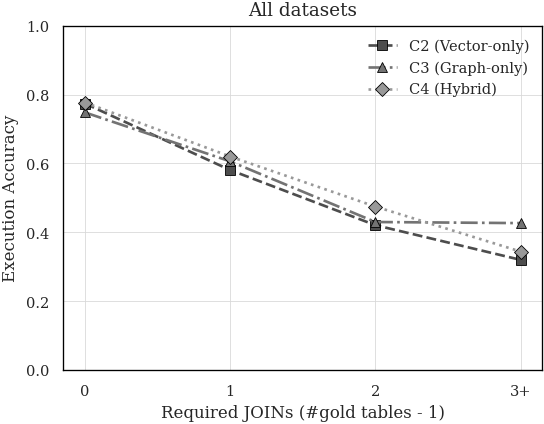

condition,C2,C3,C4,gain_C4_minus_C2,gain_C4_minus_C3
join_bucket,,,,,
0,0.7736,0.7479,0.7768,0.0032,0.0289
1,0.5806,0.6058,0.6198,0.0392,0.0140
2,0.4207,0.4299,0.4746,0.0539,0.0447
3+,0.3200,0.4267,0.3441,0.0241,-0.0826


Higher buckets should show larger C4-C2 gain (widening advantage).
Saved figure: 05_rq3_join_path_acc.png, 05_rq3_join_path_acc.pdf


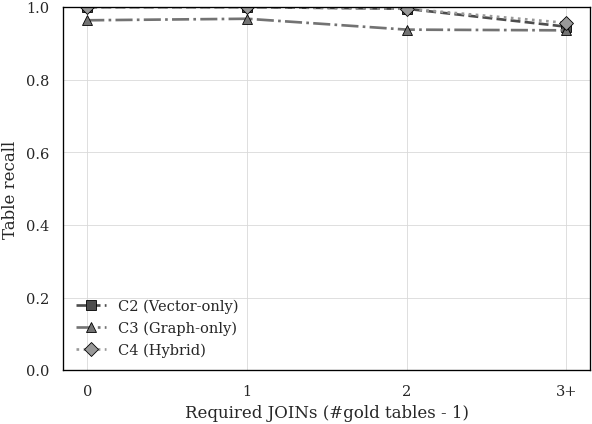

In [1]:
# ============================================================================
# 05_rq3_join_complexity.ipynb
# ----------------------------------------------------------------------------
# Beyond Full-Schema Prompting: A Graph-based Semantic Layer for Text-to-SQL
#
# RQ3 (core / killer figure): Does the graph-based advantage grow as multi-table
#      JOIN complexity increases? Plots EX vs JOIN count for C2 (vector) vs C3
#      (graph) vs C4 (hybrid), expecting the hybrid gain to widen at 3-4+ tables.
#
# Consumes : results/tables/generation_results.csv (or *_smoke.csv)
# Produces : 05_rq3_ex_by_joins.{png,pdf}      the killer crossing figure
#            05_rq3_join_path_acc.{png,pdf}
#            05_rq3_join_table.{csv,tex}
#
# Anonymity: no filesystem paths are printed.
# ============================================================================


# %% [markdown]
# ## Cell 1 - Load configuration + results

# %%
%run 00_setup_and_config.ipynb


# %%
def load_results():
    full = TABLES_DIR / "generation_results.csv"
    smoke = TABLES_DIR / "generation_results_smoke.csv"
    if full.exists():
        df = pd.read_csv(full); print(f"Loaded full results: n={len(df)}.")
    elif smoke.exists():
        df = pd.read_csv(smoke); print(f"[warning] using SMOKE data (n={len(df)}).")
    else:
        raise FileNotFoundError("Run notebook 02 first.")
    return df

res = load_results()


# %% [markdown]
# ## Cell 2 - Bucket questions by JOIN complexity
# n_join_gold = (#gold tables - 1) is the proxy for required JOINs. We bucket
# 0,1,2,3+ so sparse high-JOIN cells still have enough samples.

# %%
RQ3_CONDITIONS = ["C2", "C3", "C4"]
rq3 = res[res["condition"].isin(RQ3_CONDITIONS)].dropna(subset=["exec_match"]).copy()

def join_bucket(n):
    return "3+" if n >= 3 else str(int(n))
rq3["join_bucket"] = rq3["n_join_gold"].apply(join_bucket)
BUCKET_ORDER = ["0", "1", "2", "3+"]

print("Rows per (condition, join_bucket):")
display(rq3.pivot_table(index="join_bucket", columns="condition",
                        values="qid", aggfunc="count").reindex(BUCKET_ORDER))


# %% [markdown]
# ## Cell 3 - EX by JOIN bucket x condition (table)

# %%
rq3_table = (rq3.groupby(["dataset", "condition", "join_bucket"])
               .agg(n=("qid", "count"), EX=("exec_match", "mean"))
               .reset_index())
rq3_table["EX"] = rq3_table["EX"].round(4)
display(rq3_table.pivot_table(index=["dataset", "join_bucket"],
                              columns="condition", values="EX"))
save_table(rq3_table, "05_rq3_join_table")


# %% [markdown]
# ## Cell 4 - Killer figure: EX vs JOIN count, one line per condition
# Pooled across datasets by default (toggle PER_DATASET). Grayscale with distinct
# line styles + markers so C2/C3/C4 read clearly in B/W. dpi 600, png+pdf.

# %%
PER_DATASET = False    # True -> one panel per dataset

def plot_ex_by_joins(df, per_dataset=False):
    if per_dataset:
        datasets = sorted(df["dataset"].unique())
    else:
        datasets = ["ALL"]
    fig, axes = plt.subplots(1, len(datasets),
                             figsize=(4.8 * len(datasets), 3.8), squeeze=False)
    for ax, ds in zip(axes[0], datasets):
        sub = df if ds == "ALL" else df[df["dataset"] == ds]
        conds = [c for c in RQ3_CONDITIONS if c in sub["condition"].unique()]
        for c in conds:
            g = (sub[sub["condition"] == c].groupby("join_bucket")["exec_match"]
                 .mean().reindex(BUCKET_ORDER))
            st = CONDITION_STYLE.get(c, {})
            ax.plot(range(len(BUCKET_ORDER)), g.values,
                    color=st.get("color", "0.3"),
                    linestyle=st.get("linestyle", "-"),
                    marker=st.get("marker", "o"),
                    markersize=6, linewidth=1.6, markeredgecolor="black",
                    markeredgewidth=0.5, label=f"{c} ({CONDITIONS[c]})")
        ax.set_xticks(range(len(BUCKET_ORDER)))
        ax.set_xticklabels(BUCKET_ORDER)
        ax.set_ylim(0, 1.0)
        ax.set_xlabel("Required JOINs (#gold tables - 1)")
        ax.set_ylabel("Execution Accuracy")
        ax.set_title("All datasets" if ds == "ALL" else DATASETS.get(ds, ds))
        ax.legend()
    save_figure(fig, "05_rq3_ex_by_joins")
    plt.show()

plot_ex_by_joins(rq3, PER_DATASET)


# %% [markdown]
# ## Cell 5 - Quantify the widening gain (C4 minus C2) by JOIN bucket
# The RQ3 claim is that (EX_C4 - EX_C2) increases with JOIN count.

# %%
def widening_gain(df):
    piv = (df.groupby(["join_bucket", "condition"])["exec_match"]
             .mean().unstack("condition").reindex(BUCKET_ORDER))
    if not {"C2", "C4"}.issubset(piv.columns):
        return None
    piv["gain_C4_minus_C2"] = piv["C4"] - piv["C2"]
    if "C3" in piv.columns:
        piv["gain_C4_minus_C3"] = piv["C4"] - piv["C3"]
    return piv.round(4)

gain = widening_gain(rq3)
if gain is not None:
    display(gain)
    # correlation between bucket index and the C4-C2 gain (monotonic widening?)
    idx = np.arange(len(gain))
    valid = gain["gain_C4_minus_C2"].notna()
    if valid.sum() >= 2:
        r, p = stats.pearsonr(idx[valid.values],
                              gain["gain_C4_minus_C2"][valid].values) \
               if 'stats' in dir() else (np.nan, np.nan)
    print("Higher buckets should show larger C4-C2 gain (widening advantage).")
else:
    print("Need C2 and C4 rows across buckets (full run).")


# %% [markdown]
# ## Cell 6 - Optional: join-path accuracy vs JOIN count
# Uses table_recall as a stand-in for whether the needed join tables were
# retrieved (a precondition for correct multi-table JOINs).

# %%
def plot_join_recall(df):
    conds = [c for c in RQ3_CONDITIONS if c in df["condition"].unique()]
    if not conds:
        print("No conditions for join-recall plot.")
        return
    fig, ax = plt.subplots(figsize=(5.2, 3.8))
    for c in conds:
        g = (df[df["condition"] == c].groupby("join_bucket")["table_recall"]
             .mean().reindex(BUCKET_ORDER))
        st = CONDITION_STYLE.get(c, {})
        ax.plot(range(len(BUCKET_ORDER)), g.values,
                color=st.get("color", "0.3"), linestyle=st.get("linestyle", "-"),
                marker=st.get("marker", "o"), markersize=6, linewidth=1.6,
                markeredgecolor="black", markeredgewidth=0.5,
                label=f"{c} ({CONDITIONS[c]})")
    ax.set_xticks(range(len(BUCKET_ORDER)))
    ax.set_xticklabels(BUCKET_ORDER)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Required JOINs (#gold tables - 1)")
    ax.set_ylabel("Table recall")
    ax.legend()
    save_figure(fig, "05_rq3_join_path_acc")
    plt.show()

plot_join_recall(rq3)